# Notebook 03 - Segmentation et d?tection

Nous avons pour objectif de segmenter la voiture dans une ROI manuelle puis de d?tecter des points caract?ristiques. Cette ?tape initialise le suivi sans utiliser `groundtruth.txt`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence, preprocess_image
from src.segmentation import otsu_segmentation, adaptive_segmentation, clean_mask, keep_largest_component, paste_roi_mask_to_full_image
from src.detection import detect_edges_canny, detect_good_features, filter_points_inside_mask
from src.visualization import draw_bbox, draw_points

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## ROI manuelle

Nous d?finissons une ROI manuelle autour de la voiture dans la premi?re frame. La ROI est un choix humain simple, not? `(x, y, w, h)`. Elle ne provient pas du fichier `groundtruth.txt`.

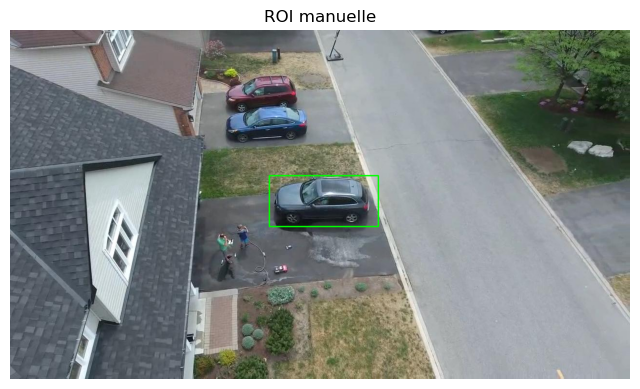

In [2]:
image_paths = load_image_sequence(IMG_DIR)
frame = load_image(image_paths[0])
gray = preprocess_image(frame)

roi = (535, 300, 225, 105)  # x, y, w, h - ROI manuelle autour de la voiture
x, y, w, h = roi
roi_frame = frame[y:y+h, x:x+w]
gray_roi = gray[y:y+h, x:x+w]

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(draw_bbox(frame, roi), cv2.COLOR_BGR2RGB))
plt.title("ROI manuelle")
plt.axis("off")
plt.show()

Nous observons que la ROI contient la voiture et une marge autour d'elle. Cette marge aide la segmentation et la d?tection de points.

## Otsu et Adaptive Threshold

Otsu cherche automatiquement un seuil global. Adaptive Threshold calcule un seuil local, plus robuste lorsque l'illumination varie dans la ROI.

In [3]:
otsu_mask = keep_largest_component(clean_mask(otsu_segmentation(gray_roi), kernel_size=(5, 5), closing_iter=2, opening_iter=1))
adaptive_mask = keep_largest_component(clean_mask(adaptive_segmentation(gray_roi), kernel_size=(5, 5), closing_iter=2, opening_iter=1))

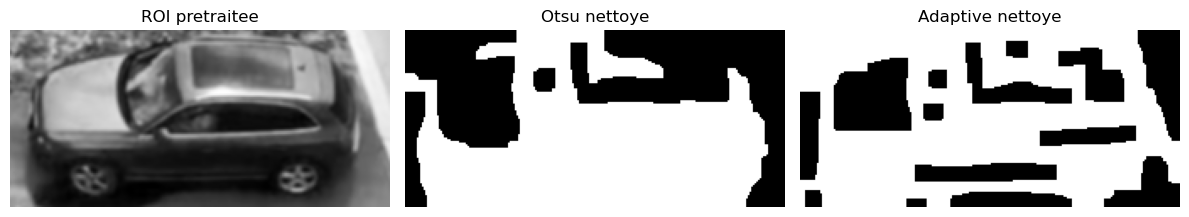

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_roi, cmap="gray"); axes[0].set_title("ROI pretraitee")
axes[1].imshow(otsu_mask, cmap="gray"); axes[1].set_title("Otsu nettoye")
axes[2].imshow(adaptive_mask, cmap="gray"); axes[2].set_title("Adaptive nettoye")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FRAMES_DIR / "segmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Nous interpr?tons les masques en regardant quelle m?thode conserve le mieux la zone de la voiture. La morphologie nettoie les petits trous et les petits artefacts. Nous gardons ensuite la plus grande composante pour ?viter de suivre des zones parasites dans la ROI.

In [5]:
selected_mask_roi = otsu_mask
selected_mask = paste_roi_mask_to_full_image(selected_mask_roi, gray.shape, roi)

## Canny et goodFeaturesToTrack

Canny met en ?vidence les contours avec `threshold1=50` et `threshold2=150`. Ensuite, `goodFeaturesToTrack` s?lectionne des coins ou points textur?s stables sur la voiture.

Nombre de points detectes: 60


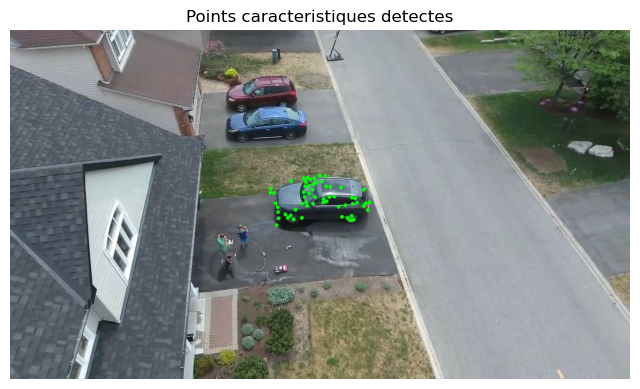

In [6]:
edges = detect_edges_canny(gray, threshold1=50, threshold2=150)
points = detect_good_features(gray, selected_mask, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7)
points = filter_points_inside_mask(points, selected_mask)

if len(points) < 8:
    print("Peu de points dans le masque segmente, detection dans toute la ROI manuelle.")
    roi_mask = paste_roi_mask_to_full_image(255 * (selected_mask_roi > -1).astype("uint8"), gray.shape, roi)
    points = detect_good_features(gray, roi_mask, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7)

print("Nombre de points detectes:", len(points))
points_frame = draw_points(frame, points)
cv2.imwrite(str(FRAMES_DIR / "points_detected.png"), points_frame)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(points_frame, cv2.COLOR_BGR2RGB))
plt.title("Points caracteristiques detectes")
plt.axis("off")
plt.show()

Nous observons les points caract?ristiques sur la voiture. Ces points serviront au calcul du champ de mouvement sparse avec Lucas-Kanade.